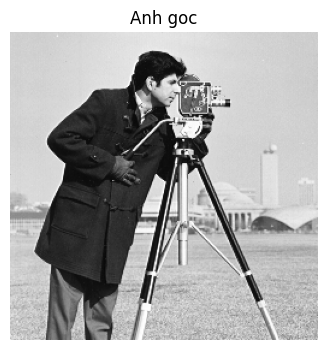

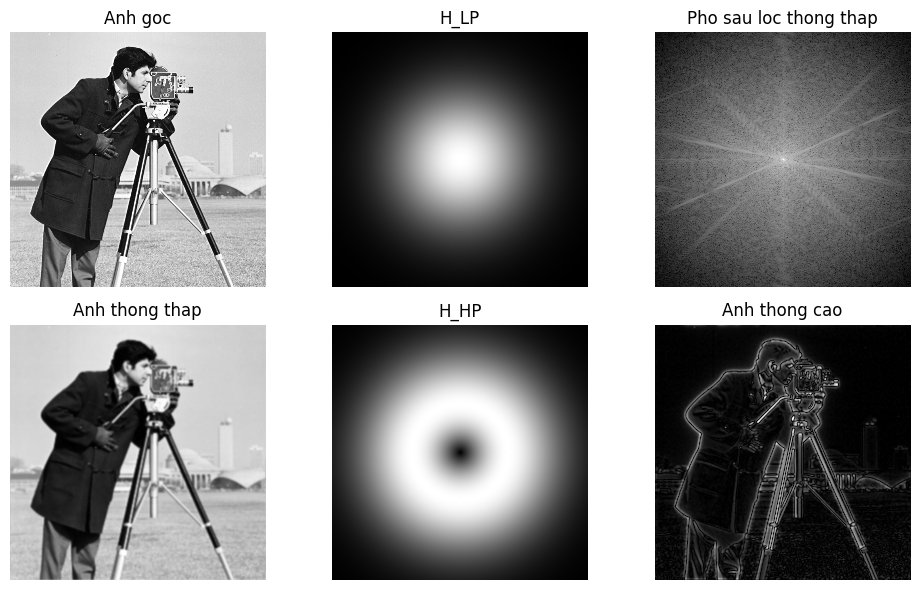

Kich thuoc anh goc: (256, 256)
Kich thuoc bo loc H_LP: (256, 256)
Kich thuoc bo loc H_HP: (256, 256)
Kich thuoc anh thong thap: (256, 256)
Kich thuoc anh thong cao: (256, 256)
Gia tri nho nhat/lon nhat cua anh goc: 22.0 255.0
Gia tri nho nhat/lon nhat cua anh thong thap: 33.362751669050496 253.58469621459
Gia tri nho nhat/lon nhat cua anh thong cao: 0.04297475914484039 28944.582965083944
Kiem tra hoan tat: code chay dung ve kich thuoc du lieu.


In [1]:
# ============================================================
# GIÁO TRÌNH: THỊ GIÁC MÁY: TỪ XỬ LÝ ẢNH ĐẾN HỌC SÂU
# BÀI CODE MINH HỌA: LỌC ẢNH TRONG MIỀN TẦN SỐ
# Chương/Mục liên quan: Chương 4 - Lọc ảnh trong miền tần số
# Ví dụ: 4.2.3
# ============================================================

# ============================================================
# MÔ TẢ
# ============================================================

# Mục đích:
# - Minh họa lọc làm mượt và lọc tách cạnh trong miền tần số.
# - Giúp người học quan sát ảnh hưởng của bộ lọc Gaussian lên phổ Fourier của ảnh.
# - Liên hệ phần code với nội dung lý thuyết về biến đổi Fourier và lọc ảnh trong miền tần số.

# Sau khi chạy code, người học cần:
# 1. Quan sát được ảnh gốc, bộ lọc làm mượt, bộ lọc tách cạnh và ảnh sau lọc.
# 2. Hiểu rằng lọc trong miền tần số được thực hiện bằng phép nhân phổ ảnh với hàm truyền của bộ lọc.
# 3. Biết thay đổi tham số D0 để quan sát ảnh hưởng đến mức độ làm mượt hoặc nhấn mạnh biên.

# Input:
# - Dữ liệu đầu vào: ảnh cameraman.png từ GitHub.
# - Kiểu dữ liệu: ảnh xám.
# - Kích thước xử lý: 256 x 256.

# Output:
# - Ảnh gốc.
# - Bộ lọc làm mượt H_LP.
# - Phổ sau lọc làm mượt.
# - Ảnh sau lọc làm mượt.
# - Bộ lọc tách cạnh H_HP.
# - Ảnh sau lọc tách cạnh.

# Lưu ý
# Đoạn code này được xây dựng với sự hỗ trợ của công cụ AI.
# Giảng viên đã đọc, kiểm tra và hiệu chỉnh nhằm bảo đảm tính chính xác,
# tính sư phạm và sự phù hợp với nội dung lý thuyết trong giáo trình.

# Người học không chỉ chạy code để xem kết quả, mà cần hiểu:
# - Code đang minh họa nội dung lý thuyết nào;
# - Các bước xử lý tương ứng với công thức hoặc thuật toán nào;
# - Kết quả đầu ra có hợp lý hay không;
# - Khi thay đổi tham số, kết quả thay đổi như thế nào.

# ============================================================
# 1. CÀI ĐẶT VÀ IMPORT THƯ VIỆN
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from urllib.request import urlopen

# ============================================================
# 2. TẢI DỮ LIỆU ĐẦU VÀO
# ============================================================

def read_gitlab_image(url):
    resp = urlopen(url)
    img = np.asarray(bytearray(resp.read()), dtype=np.uint8)
    return cv2.imdecode(img, cv2.IMREAD_GRAYSCALE)

# Đọc ảnh từ kho GitHub
image_uri = "https://github.com/lthavnu/cv-book/raw/main/images/cameraman.png"
I = read_gitlab_image(image_uri)

if I is None:
    raise FileNotFoundError("Không tìm thấy file cameraman.png")

# Chuẩn hóa kích thước ảnh và kiểu dữ liệu
I = cv2.resize(I, (256, 256))
I = I.astype(np.float32)

# Thiết lập các tham số đầu vào
M = N = 256
D0 = 48
sigma = 0.85

# ============================================================
# 3. HIỂN THỊ ẢNH ĐẦU VÀO
# ============================================================

plt.figure(figsize=(4, 4))
plt.imshow(I, cmap='gray')
plt.title('Anh goc')
plt.axis('off')
plt.show()

# ============================================================
# 4. XỬ LÝ CHÍNH
# ============================================================

# Biến đổi Fourier ảnh đầu vào
F = np.fft.fft2(I)

# Đưa gốc tần số về tâm ảnh phổ
F_shift = np.fft.fftshift(F)

# Tạo lưới tọa độ tần số với tâm ở giữa ảnh
u = np.arange(-N//2, N//2)
v = np.arange(-M//2, M//2)
U, V = np.meshgrid(u, v)

# Tính khoảng cách từ mỗi điểm tần số đến gốc tần số
D = np.sqrt(U**2 + V**2)

# Dòng code tương ứng với công thức bộ lọc làm mượt Gaussian
H_LP = np.exp(-(D**2) / (2 * D0**2))

# Dòng code tương ứng với bộ lọc tách cạnh được xây dựng từ H_LP
H_HP = 2 * np.pi * D * H_LP

# Lọc trong miền tần số bằng phép nhân phổ ảnh với bộ lọc
G_LP = F_shift * H_LP
G_HP = F_shift * H_HP

# Biến đổi ngược về miền không gian
I_LP = np.fft.ifft2(np.fft.ifftshift(G_LP))
I_HP = np.fft.ifft2(np.fft.ifftshift(G_HP))

# Lấy biên độ ảnh kết quả
I_LP = np.abs(I_LP)
I_HP = np.abs(I_HP)

# ============================================================
# 5. HIỂN THỊ KẾT QUẢ
# ============================================================

plt.figure(figsize=(10, 6))

plt.subplot(2, 3, 1)
plt.imshow(I, cmap='gray')
plt.title('Anh goc')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(H_LP, cmap='gray')
plt.title('H_LP')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(np.log(1 + np.abs(G_LP)), cmap='gray')
plt.title('Pho sau loc thong thap')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(I_LP, cmap='gray')
plt.title('Anh thong thap')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(H_HP, cmap='gray')
plt.title('H_HP')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(I_HP, cmap='gray')
plt.title('Anh thong cao')
plt.axis('off')

plt.tight_layout()
plt.show()

# ============================================================
# 6. KIỂM TRA KẾT QUẢ
# ============================================================

print("Kich thuoc anh goc:", I.shape)
print("Kich thuoc bo loc H_LP:", H_LP.shape)
print("Kich thuoc bo loc H_HP:", H_HP.shape)
print("Kich thuoc anh thong thap:", I_LP.shape)
print("Kich thuoc anh thong cao:", I_HP.shape)

print("Gia tri nho nhat/lon nhat cua anh goc:", np.min(I), np.max(I))
print("Gia tri nho nhat/lon nhat cua anh thong thap:", np.min(I_LP), np.max(I_LP))
print("Gia tri nho nhat/lon nhat cua anh thong cao:", np.min(I_HP), np.max(I_HP))

assert I.shape == (M, N)
assert H_LP.shape == (M, N)
assert H_HP.shape == (M, N)
assert I_LP.shape == (M, N)
assert I_HP.shape == (M, N)

print("Kiem tra hoan tat: code chay dung ve kich thuoc du lieu.")

# ============================================================
# 7. GỢI Ý THỬ NGHIỆM CHO NGƯỜI HỌC
# ============================================================

# 1. Thay đổi D0 = 20, 48, 80 để quan sát mức độ làm mượt của ảnh thông thấp.
# 2. So sánh ảnh thông cao khi D0 nhỏ và khi D0 lớn.
# 3. Thay ảnh đầu vào bằng một ảnh xám khác để kiểm tra tác động của bộ lọc trên nội dung ảnh khác nhau.